In [3]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
warnings.filterwarnings("ignore")

In [5]:
'''
In this cell, we will define functions that: 
>> Remove outliers from data
>> Check for stationarity in the mean using Augmented Dickey-Fuller test
>> Plot rolling mean variance
'''
def remove_outliers(data):
    data = data.copy() # Do not modify the= original time-series
    mean = data.mean()
    std = data.std()
    z_scores = (data - mean) / std
    data.loc[np.abs(z_scores) >=3] = data.median()
    return data

def is_stationary(data):
    result = adfuller(data)
    p_value = result[1]
    return p_value < 0.05

def plot_rolling_mean_variance(data, window, title, path_to_save):
    rolling_mean = data.rolling(window).mean()
    rolling_variance = data.rolling(window).var()
    plt.figure(figsize=(8, 6))
    plt.plot(rolling_mean, color="red", label="rolling mean")
    plt.plot(rolling_variance, color="orange", label="rolling variance")
    plt.title(title)
    plt.legend(loc="upper right")
    plt.savefig(path_to_save)
    plt.show()

In [6]:
# Put this notebook in the python file
def load_data(path_to_data):
    data = pd.read_csv(path_to_data)
    return data

def clean_data(data):
    '''
    This function takes the loaded dataset and applies necessary cleaning techniques to it and
    returns a new dataset
    '''
    # Sort values by time
    data = data.sort_values(by="Month") # Sort values by time
    # Verify if time steps are consistent
    data["time"] = pd.to_datetime(data["Month"], errors="coerce")
    time_diffs = data["time"].diff(1)
    month_diffs = np.round(time_diffs.dt.days / 30)
    # If time steps are consistent, then the maximum and minimum values of month_diffs must be one
    is_time_consistent = month_diffs.min() == month_diffs.max() == 1
    print("Is time consistent: ", is_time_consistent)
    
    # Remove outliers from data
    clean_data = remove_outliers(data["Passengers"])
    #print("Clean data shape: ", clean_data.shape)
    
    clean_data = pd.DataFrame(
        {
            "time": data["time"],
            "Passengers": clean_data
        }
    )
    # Set time column as index
    clean_data = clean_data.set_index("time")
    clean_data.describe()
    
    print("Shape of clean data: ", clean_data.shape)
    # Save clean data
    clean_data.to_csv(os.path.join(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\data", "cleaned_data.csv"))
    return clean_data
    

In [7]:
'''
In this cell, we will: 
>> Load the dataset
>> Display information and description of the dataset
>> Sort the values by time
>> Set time as index
>> Handle missing values
>> Check for inconsistent time steps
>> Remove outliers from the dataset
'''
data = load_data(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\data\airline-passengers.csv")
print(data.head(5)) # Display the first 5 rows
print(data.tail(5)) # Display the last 5 rows of the data
print(data.info()) # Display data information
print(data.describe()) # Display data description

# Check for missing values
print("Number of missing values: ", data.isna().sum())

# Clean dataset
clean_data = clean_data(data)

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
       Month  Passengers
139  1960-08         606
140  1960-09         508
141  1960-10         461
142  1960-11         390
143  1960-12         432
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000
Number of missing values:  Month         0
Passengers    0
dtype: int64
Is time consistent:  True
Shape of clean data:  (144, 1)


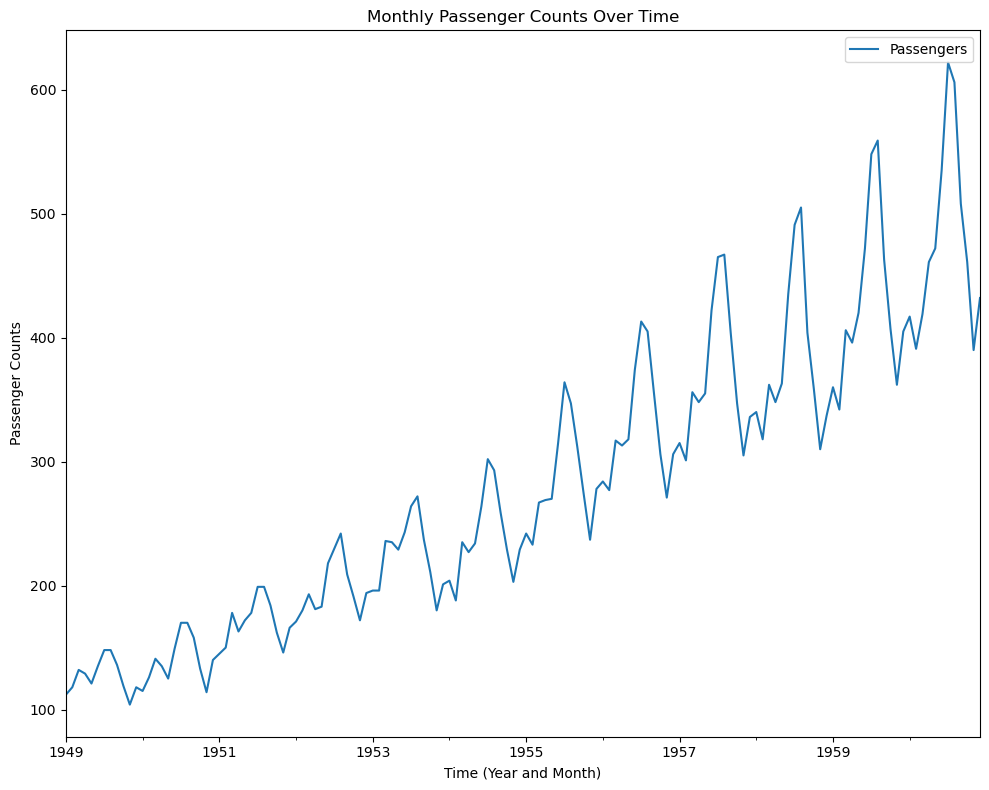

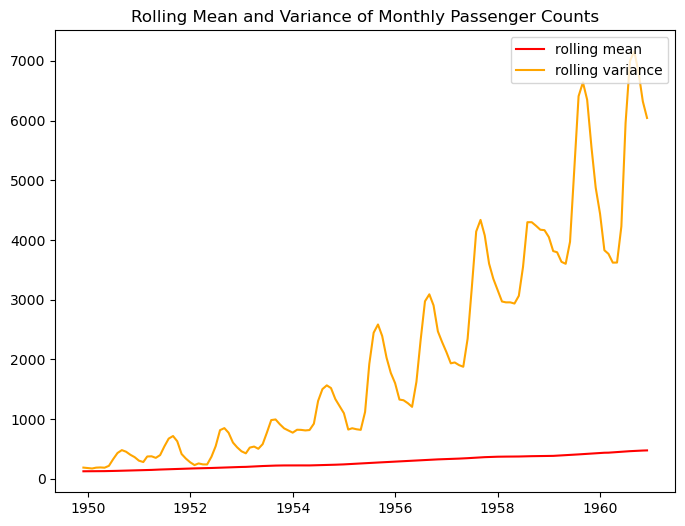

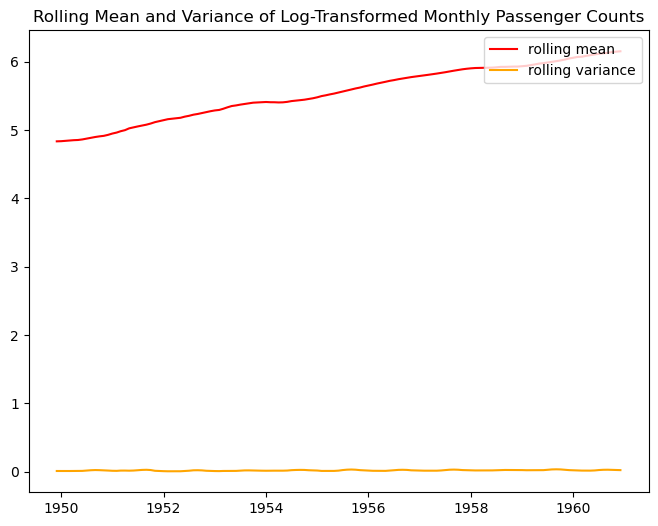

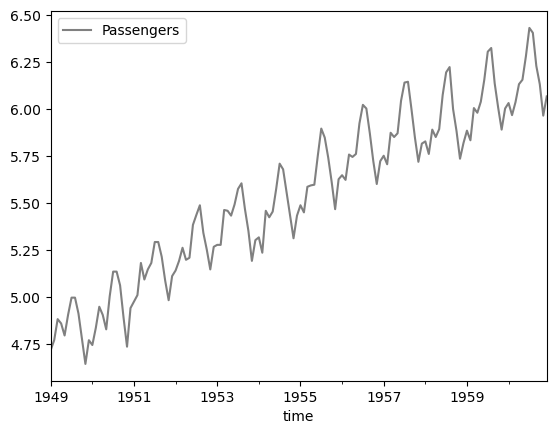

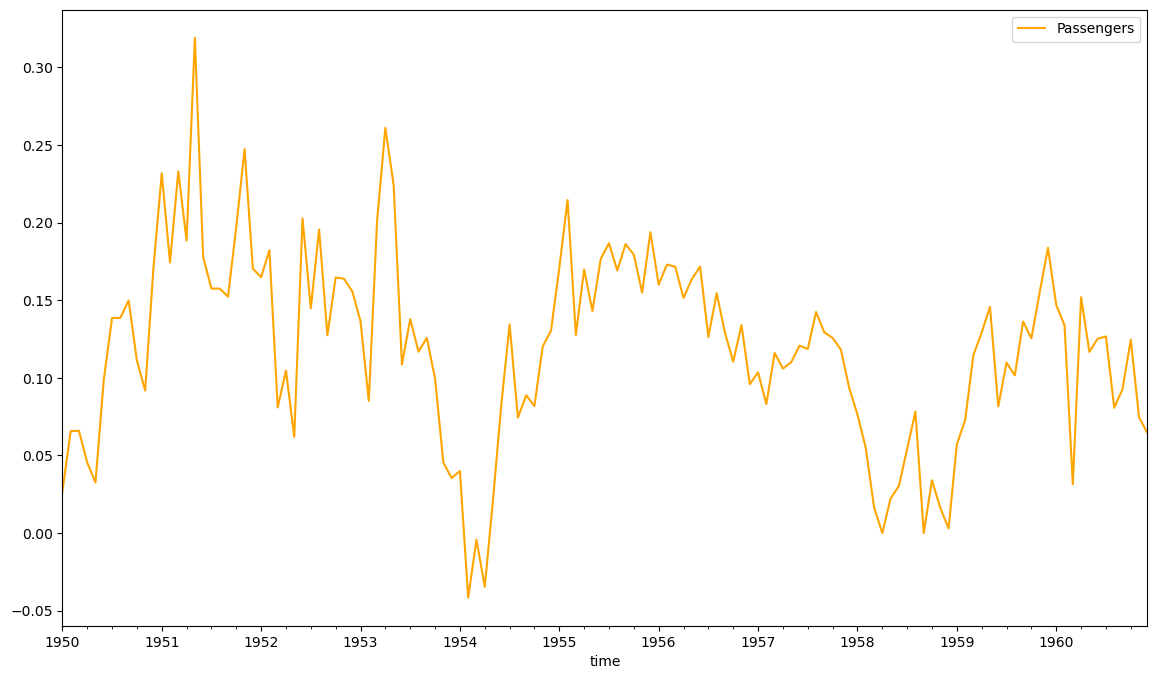

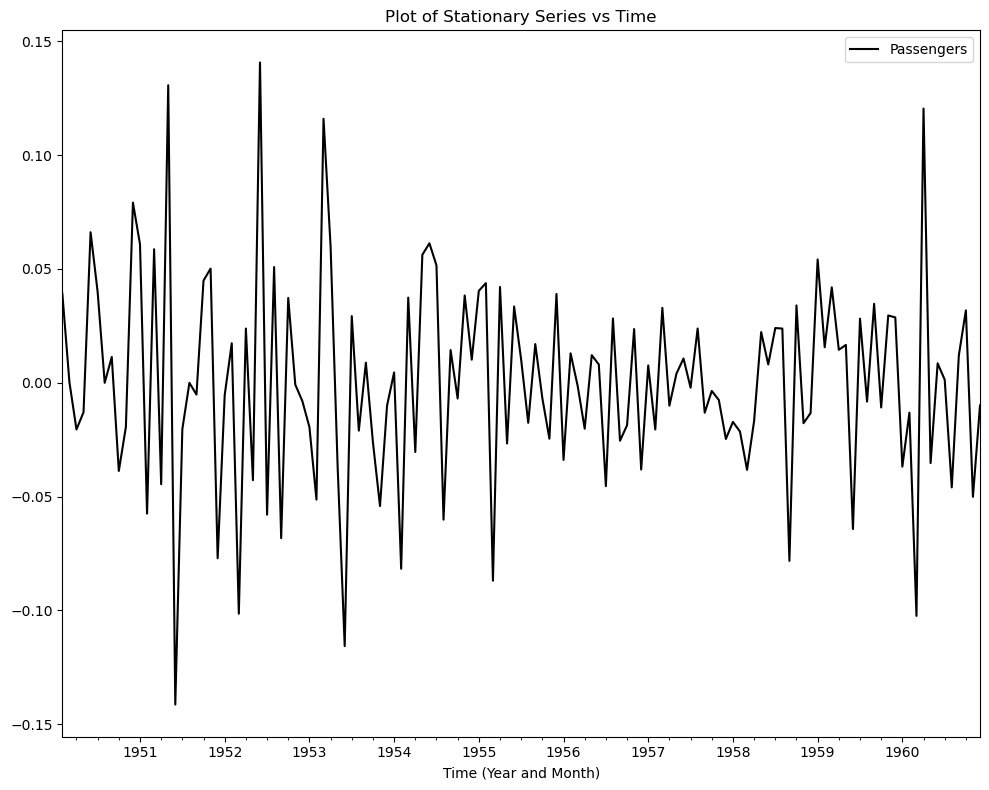

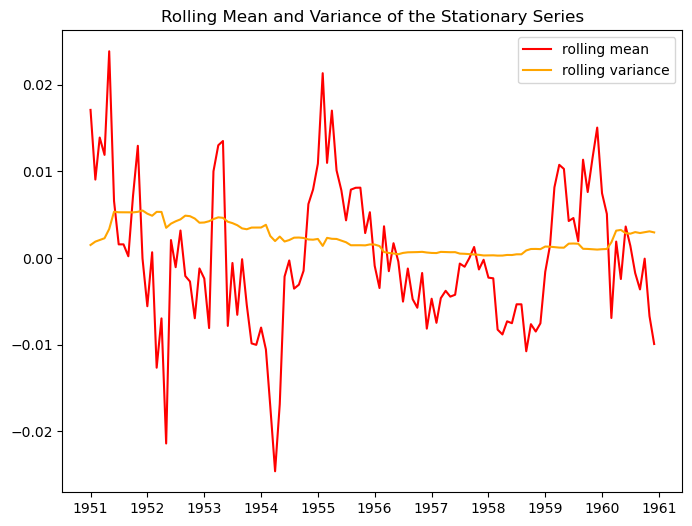

Is stationary:  True


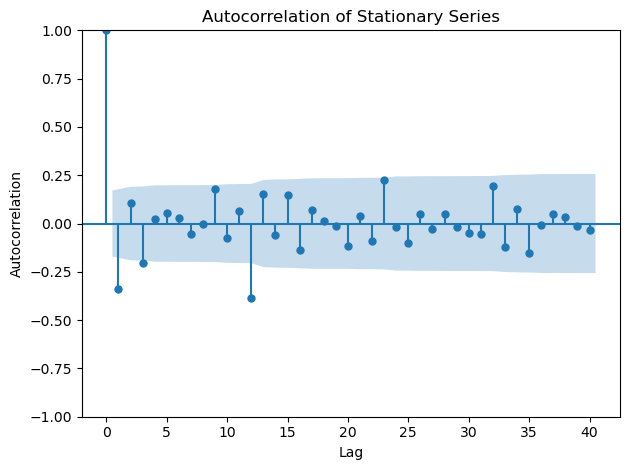

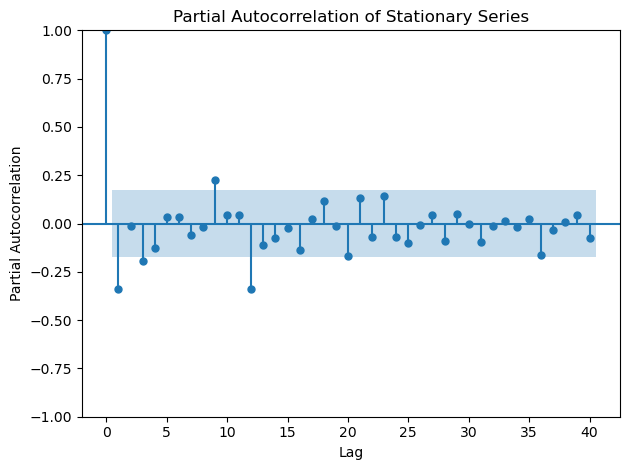

'\nFrom the plots of the ACF and the PACF, we can determine the parameters of the SARIMA model as: \n>> Non-seasonal parameters: p=1, q=1, and d=1 (first order differencing that removed trend)\n>> Seasonal parameters: P=1, Q=1, and D=1 (seasonal differencing)\nNB: In the ACF and PACF plots, all values in the confidence interval are insignificant\n'

In [8]:
'''
In this cell, we will: 
>> Plot the time-series
>> Check for trend and seasonality
>> Verify if the time-series is stationary (Augmented Dickey-Fuller, and rolling mean/variance) 
  and take steps to make the time-series stationary if it is not
>> Plot the autocorrelation and partial autocorrelation functions
>> Determine the parameters, p, d, q, P, D, Q, and s of the SARIMA model
'''
clean_data.plot(figsize=(10, 8))
plt.title("Monthly Passenger Counts Over Time")
plt.xlabel("Time (Year and Month)")
plt.ylabel("Passenger Counts")
plt.tight_layout()
plt.savefig(os.path.join(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\plots", "monthly_passenger_counts.png"))
plt.show()

# Observe from the time-series plot that the time-series has increasing trend and shows yearly seasonality
# To model this time-series, we are going to use a SARIMA model since it can capture seasonality and trend

#  Plot the rolling mean and variance
plot_rolling_mean_variance(clean_data, window=12, title="Rolling Mean and Variance of Monthly Passenger Counts", \
                          path_to_save=os.path.join(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\plots", "passenger_count_rolling_mean_var.png"))

# The rolling mean plot appears to be a straight line indicating constant mean
# The rolling variance plot shows increasing trend demonstrating heteroscedasticity which is bad for SARIMA
# We are going to stabilize the variance using the log transform
transformed_data = np.log(clean_data)
# Plot rolling mean and variance of transformed series
plot_rolling_mean_variance(transformed_data, window=12, title="Rolling Mean and Variance of Log-Transformed Monthly Passenger Counts",\
                          path_to_save=os.path.join(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\plots", "log-transformed_rolling_mean_var.png"))

# Observe from the plot that the new plot of the rolling variance slightly varies which is what we want. 
# It is the log-transformed series that we will fit into the SARIMA model

# Plot the log series
transformed_data.plot(color="grey")


s = 12 # seasonal component corresponding to 12 months
diff_series = transformed_data.diff(s) # Seasonal differencing
diff_series.dropna(inplace=True)

# Now let's plot the differenced time-series to ensure that seanonality has been removed
diff_series.plot(figsize=(14, 8), color="orange")

# Remove trend by applying first-order differencing
detrended_series = diff_series.diff(1)
detrended_series.dropna(inplace=True)

detrended_series.plot(figsize=(10, 8), color="black") # This is the stationary series
plt.xlabel("Time (Year and Month)")
plt.title("Plot of Stationary Series vs Time")
plt.tight_layout()
plt.savefig(os.path.join(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\plots", "stationary_series.png"))

plot_rolling_mean_variance(detrended_series, window=12, title="Rolling Mean and Variance of the Stationary Series", \
                          path_to_save=os.path.join(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\plots", "stationary_rolling_mean_var.png"))
print("Is stationary: ", is_stationary(detrended_series))

# The detrended series is now stationary as seen in the rolling mean and variance plot
# Now, let us plot the autcorrelation function (ACF) and partial autocorrelation function (PACF) to determine the model parameters
plot_acf(detrended_series, lags=40)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of Stationary Series")
plt.tight_layout()
plt.savefig(os.path.join(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\plots", "ACF_stationary_series.png"))

plot_pacf(detrended_series, lags=40)
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.title("Partial Autocorrelation of Stationary Series")
plt.tight_layout()
plt.savefig(os.path.join(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\plots", "PACF_stationary_series.png"))
plt.show()

'''
From the plots of the ACF and the PACF, we can determine the parameters of the SARIMA model as: 
>> Non-seasonal parameters: p=1, q=1, and d=1 (first order differencing that removed trend)
>> Seasonal parameters: P=1, Q=1, and D=1 (seasonal differencing)
NB: In the ACF and PACF plots, all values in the confidence interval are insignificant
'''

In [9]:
# This will be put in modeling python files
def train_sarima(train_data, order, seasonal_order, s): 
    '''
    Note that order and seasonal_order must be tuples, train_data must be a time-series, and s an integer
    '''
    # Load SARIMA model
    model = SARIMAX(
        train_data, 
        order = (p, d, q),
        seasonal_order = (P, D, Q, s)
    )
    
    # Train the model
    model_fit = model.fit()
    return model_fit

def forecast(model_fit, test_data):
    predictions = model_fit.get_forecast(steps=test_data.size)
    return predictions.predicted_mean

In [10]:
'''
In this cell, we are going to: 
>> Split the dataset into training and testing sets
>> train the SARIMA model with the parameters we obtained
>> Perform multi-step forecasting over a short horizon
'''
# The time-series we will fit into the model is the log-transformed time-series
training_length = int(0.9 * transformed_data.size)
train_data, test_data = transformed_data[:training_length], transformed_data[training_length:]
print("train data shape: ", train_data.shape)
print("test data shape: ", test_data.shape)

# Model parameters
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 12

# Train SARIMA model 
model_fit = train_sarima(
    train_data, 
    order=(p, d, q),
    seasonal_order=(P, D, Q), s=s
)

# Forecast the next 15 values
predictions = forecast(model_fit, test_data)

# Convert data back to the original form
scaled_predictions = np.exp(predictions)
scaled_test_data = np.exp(test_data)

# Round predictions and test data to the nearest integer since all passenger values are integers
scaled_predictions = np.round(scaled_predictions).astype(int)
scaled_test_data = np.round(scaled_test_data).astype(int)
print(scaled_predictions) # Forecasted values
print(scaled_test_data) # Original values

# Save the actual and predicted values in a csv file
saved_data = pd.DataFrame(
    {
        "time": scaled_test_data.index.strftime("%Y-%m"),
        "Actual Passengers": scaled_test_data.values.flatten(),
        "Predicted Passengers": scaled_predictions.values.flatten()
    }
)
saved_data.to_csv(os.path.join(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\results", "forecasts.csv"), index=False)
print(saved_data.head(10))
print(saved_data.describe())

train data shape:  (129, 1)
test data shape:  (15, 1)
1959-10-01    408
1959-11-01    355
1959-12-01    393
1960-01-01    409
1960-02-01    389
1960-03-01    454
1960-04-01    442
1960-05-01    461
1960-06-01    534
1960-07-01    607
1960-08-01    615
1960-09-01    513
1960-10-01    450
1960-11-01    392
1960-12-01    434
Freq: MS, Name: predicted_mean, dtype: int32
            Passengers
time                  
1959-10-01         407
1959-11-01         362
1959-12-01         405
1960-01-01         417
1960-02-01         391
1960-03-01         419
1960-04-01         461
1960-05-01         472
1960-06-01         535
1960-07-01         622
1960-08-01         606
1960-09-01         508
1960-10-01         461
1960-11-01         390
1960-12-01         432
      time  Actual Passengers  Predicted Passengers
0  1959-10                407                   408
1  1959-11                362                   355
2  1959-12                405                   393
3  1960-01                417   

In [11]:
def evaluate_model(test_data, predictions):
    '''
    This function calculates and returns RMSE, MSE, MAE, and MAPE
    The function returns a dictionary
    '''
    rmse = root_mean_squared_error(test_data, predictions)
    mse = mean_squared_error(test_data, predictions)
    mae = mean_absolute_error(test_data, predictions)
    mape = mean_absolute_percentage_error(test_data, predictions)
    metrics =  {
        "rmse": rmse, 
        "mse": mse,
        "mae": mae, 
        "mape": mape
    }
    return metrics


Model Evaluation Metrics on Test Data
rmse:  12.73
mse:  162.0
mae:  9.33
mape:  0.02


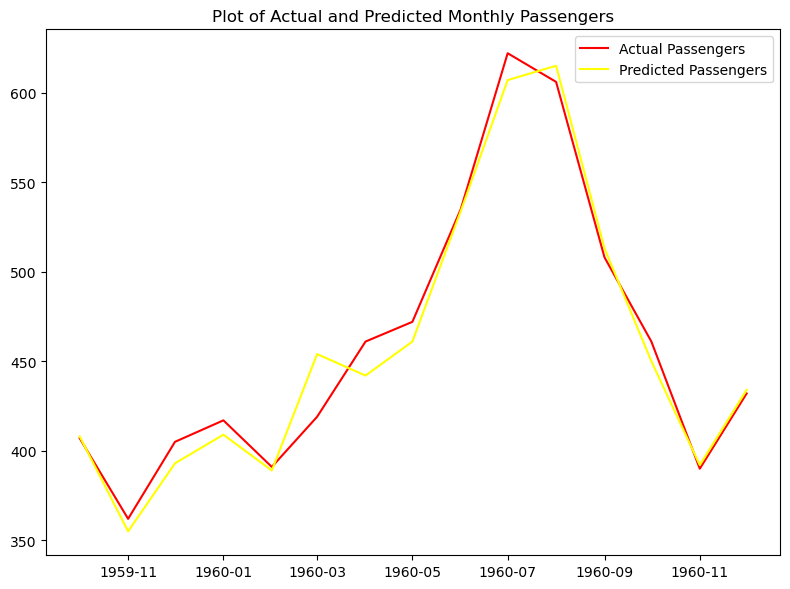

In [12]:
'''
In this cell, we will: 
>> Evaluate the performance of the SARIMA model using RMSE, MSE, MAE, and MAPE and display them
>> Plot the actual and forecasted values on the same axis
'''
# Calculate performance metrics
metrics = evaluate_model(scaled_test_data, scaled_predictions) # metrics is a dictionary
rmse = metrics["rmse"]
mse = metrics["mse"]
mae = metrics["mae"]
mape = metrics["mape"]

# Display performance metrics
print("Model Evaluation Metrics on Test Data")
print("rmse: ", np.round(rmse, 2))
print("mse: ", np.round(mse, 2))
print("mae: ", np.round(mae, 2))
print("mape: ", np.round(mape, 2))


# Plot actual and predicted values on the same axis
plt.figure(figsize=(8, 6))
plt.plot(scaled_test_data, color="red", label="Actual Passengers")
plt.plot(scaled_predictions, color="yellow", label="Predicted Passengers")
plt.legend(loc="upper right")
plt.title("Plot of Actual and Predicted Monthly Passengers")
plt.tight_layout()
plt.savefig(os.path.join(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\plots", "actual_vs_predicted.png"))
plt.show()

In [13]:
def residuals(model_fit):
    return model_fit.resid

Residual mean:  0.02
Residual variance:  0.22


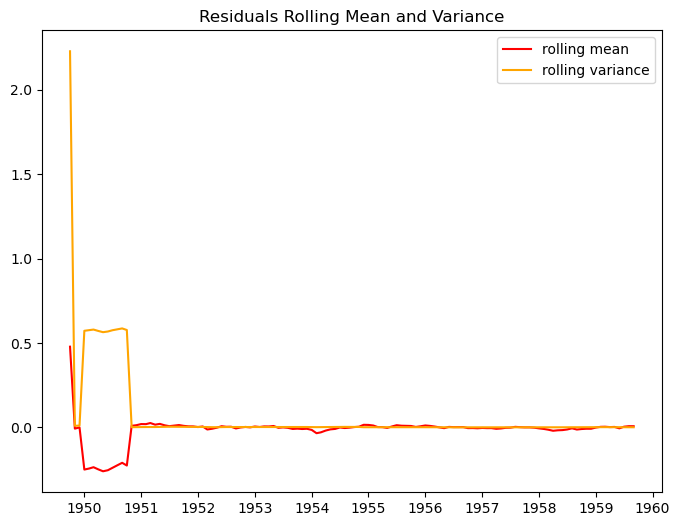

Are residuals stationary:  True


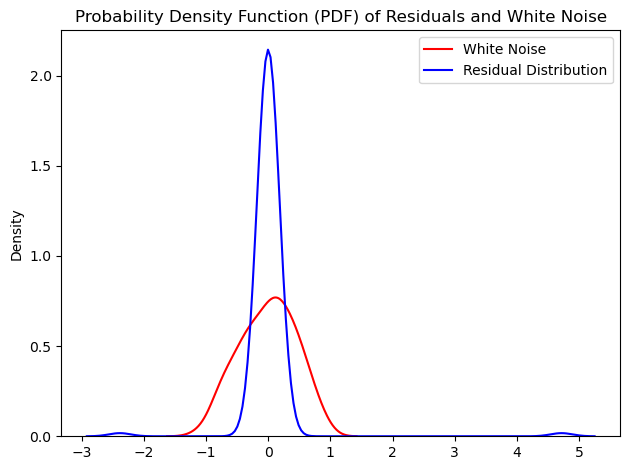

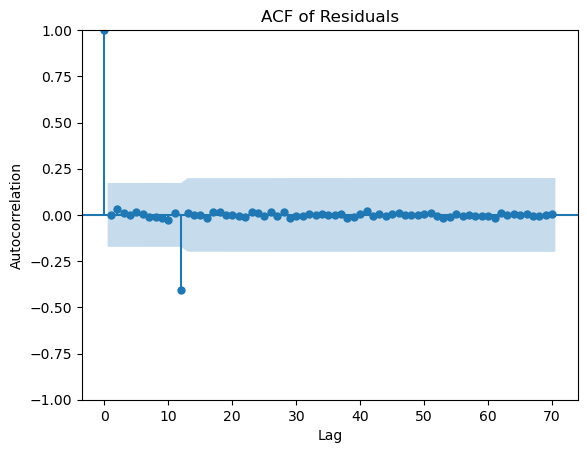

In [14]:
'''
In this cell, we will: 
>> Compute residuals and calculate residual mean and variance
>> Plot the rolling mean and variance of the residuals to verify stationarity in the mean and variance
>> Plot the distribution of the residuals and the Gaussian noise distribution on the same axis to see how well they overlap
>> Plot the ACF to determine if residual samples are uncorellated
>> Perform stationarity test using the Augmented Dickey-Fuller on the residuals
'''
residuals = residuals(model_fit)
print("Residual mean: ", np.round(residuals.mean(), 3))
print("Residual variance: ", np.round(residuals.var(), 3))

# Plot rolling mean and variance of residuals
window = 10
plot_rolling_mean_variance(residuals, window=10, title="Residuals Rolling Mean and Variance",\
                          path_to_save=os.path.join(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\plots", "residuals_rolling_mean_var.png"))

# Let us plot the distributions of the residuals and Gaussian noise
white_noise = np.random.normal(loc=0, scale=residuals.std(), size=residuals.size)
sns.kdeplot(white_noise, color="red", label="White Noise")
sns.kdeplot(residuals, color="blue", label="Residual Distribution")
plt.title("Probability Density Function (PDF) of Residuals and White Noise")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\plots", "residual_vs_white_noise_PDF.png"))

# Plot the ACF of the residuals
plot_acf(residuals, lags=70)
plt.title("ACF of Residuals")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.savefig(os.path.join(r"C:\Users\pad market\Desktop\airline-passenger-forecasting\plots", "residual_autocorrelation.png"))

# Let us do the augmented Dickey-Fuller test to determine if residuals are stationary
print("Are residuals stationary: ", is_stationary(residuals))

In [32]:
# Run python files here
%run ../src/main.py

This is the main file where we will gather and run all our code


ImportError: attempted relative import with no known parent package